# Decode denoised latents

Lightweight notebook: load a `denoised_latents.pt` file (e.g. produced by `scripts/sd_clip_img2img.py`), randomly sample a few `[4, 8, 8]` latents, and decode them with SD's VAE to look at the resulting images. VAE loading/decode logic mirrors `notebooks/extract_image_embeddings.ipynb`'s `sd_vae` encoder (`extract_batch.decode`).

In [1]:
import os
import sys

import numpy as np
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [3]:
REPO_ROOT = ".."
sys.path.insert(0, REPO_ROOT)

from utils import discover_device

In [4]:
# Path to a denoised_latents.pt file, e.g. produced by scripts/sd_clip_img2img.py
DENOISED_LATENTS_PATH = os.path.join(REPO_ROOT, "outputs/sd_clip_img2img/denoised_latents.pt")

VAE_MODEL_ID = "stabilityai/sd-vae-ft-mse"  # should match whatever VAE the latents were produced/decoded with
N_SAMPLES = 6
SEED = 42

device = torch.device(discover_device())
print(f"Device: {device}")

Device: cpu


In [5]:
latents = torch.load(DENOISED_LATENTS_PATH, map_location="cpu")
assert torch.is_tensor(latents) and latents.shape[1:] == (4, 8, 8), \
    f"Expected a [N, 4, 8, 8] tensor, got {type(latents)} {getattr(latents, 'shape', None)}"
print(f"Loaded {latents.shape[0]} latents {tuple(latents.shape)} from {DENOISED_LATENTS_PATH}")

rng = np.random.default_rng(SEED)
n_show = min(N_SAMPLES, latents.shape[0])
sample_idx = rng.choice(latents.shape[0], size=n_show, replace=False)
sampled_latents = latents[sample_idx]
print(f"Randomly sampled indices: {sample_idx.tolist()}")

Loaded 500 latents (500, 4, 8, 8) from ../outputs/sd_clip_img2img/denoised_latents.pt
Randomly sampled indices: [325, 383, 216, 429, 218, 44]


In [6]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(VAE_MODEL_ID).to(device).eval()
for p in vae.parameters():
    p.requires_grad_(False)
scaling_factor = vae.config.scaling_factor

@torch.no_grad()
def decode_batch(latents_batch: torch.Tensor) -> torch.Tensor:
    """Same convention as extract_image_embeddings.ipynb's sd_vae loader: scaled latent -> [0,1] image."""
    images = vae.decode(latents_batch.to(device) / scaling_factor).sample
    return ((images.clamp(-1, 1) + 1.0) / 2.0).cpu()

/home/jhanliufu/RutishauserLab/DiffusionBANMap/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


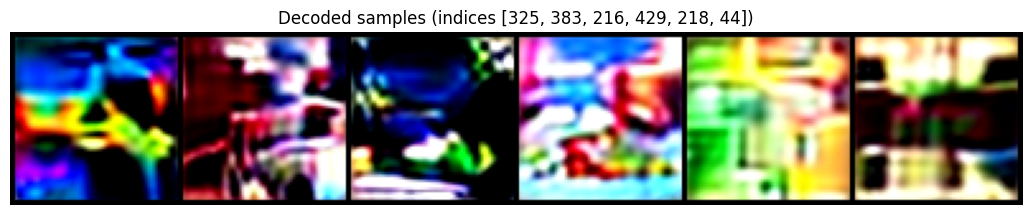

In [7]:
images = decode_batch(sampled_latents).clamp(0, 1)

grid = make_grid(images, nrow=n_show)
grid_np = grid.permute(1, 2, 0).numpy()

plt.figure(figsize=(n_show * 2, 2.2))
plt.imshow(grid_np.squeeze(-1) if grid_np.shape[-1] == 1 else grid_np,
           cmap="gray" if grid_np.shape[-1] == 1 else None)
plt.axis("off")
plt.title(f"Decoded samples (indices {sample_idx.tolist()})")
plt.tight_layout()
plt.show()